In [1]:
import astromugs as mugs
import astromugs.pipeline as pipeline
import astromugs.plotting.plot as mplt

In [2]:
import radmc3dPy as r3d

Fast (Fortran90) Mie-scattering module could not be imported. Falling back to the slower Python version.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import glob
import re
import os
import time
import subprocess
from contextlib import contextmanager
from matplotlib.collections import PolyCollection

In [4]:
import astromugs.casa.pipeline as cas

In [5]:
# TARGET MOLECULES FOR EMISSION LINES
MOLEC = ["CO","CN","CS","HCN","HCO+","N2H+","CH3OH","H2CO"]  
# PATHS
chemistry_path = Path("/home/fmeyer/Stage/Model23/chemistry_correct/")
thermal_path ="/home/fmeyer/Stage/Model23/thermal/"
time_index = 41

In [6]:
# ==============================================================================
# TARGET PARAMETERS: THE FLYING SAUCER DISK
# Source: Dutrey et al. (2025) - Edge-On Disk Study (EODS) III
# ==============================================================================

flying_saucer_params = {
    # Astrometric position registered to Epoch 2016.0
    'coord': '16h28m13.6979s -24d31m39.491s', 
    
    # Distance of the source located in the Ophiuchus cloud
    'dpc': 120., 
    
    # Systemic velocity in the LSR (Local Standard of Rest) frame
    'v_lsr': 3.72, # [km/s]
    
    # Keplerian velocity normalized at a radius of 100 au
    'v_100au': 2.32, # [km/s]
    
    # Mass of the central Class II T Tauri young stellar object
    'm_star': 0.60, # [Msun]
    
    # Disk geometry: nearly edge-on but slightly inclined
    'inclination': 87.0, # [deg] (Inclination > 85 deg produces strong tomographic projection)
    
    # Position Angle (orientation) of the disk major axis
    'pa': -3.1, # [deg]
}

# ==============================================================================
# DATA FROM ALMA ARCHIVE 2023.1.00907.S
# https://almascience.nrao.edu/aq/?observationsSortProp=project.code&observationsSortDir=asc&observationsProjectCode=2023.1.00907.S&observationsFrequency=339.483..354.618
# ==============================================================================
alma_observations = [
    {
        "antennalist": "alma.cycle10.5.cfg",
        "totaltime": "6985s",
        "refdate": "2024/06/10",
        "pwv": 0.897,
        "integration": "6.048s",
        "bmin":"0.19arcsec",
        "bmaj":"0.27arcsec",
        "beam_orientation":"100deg"
    },
    {
        "antennalist": "alma.cycle10.3.cfg",
        "totaltime": "2298s",
        "refdate": "2024/09/16",
        "pwv": 0.760,
        "integration": "6.048s",
    },
]

In [7]:
# WRITING INPUT FILES
cas.writing_input_files(chemistry_path,thermal_path,MOLEC,flying_saucer_params,verbose=True,time_index=time_index)

writing numberdens_CO.inp...
writing numberdens_CN.inp...
writing numberdens_CS.inp...
writing numberdens_HCN.inp...
writing numberdens_HCO+.inp...
writing numberdens_N2H+.inp...
writing numberdens_CH3OH.inp...
writing numberdens_H2CO.inp...

Writing lines.inp:
----------------------------

Writing gas_velocity.inp:
----------------------------

Writing gas_temperature.inp from 1D_static.dat:
----------------------------
writing gas_temperature.inp  (18000 cells)...


In [8]:
# # PLOTTING MOLECULAR DENSITIES (FROM numberdens_XX.inp)
# mplt.numberdens(species=MOLEC, path=thermal_path, vmin=1e-5, vmax=1e7, cmap='jet',
#                ncols=3, xlim=None, ylim=(-100,100), figsize=None,
#                save=False, savename='numberdens.pdf')

In [9]:
# # PLOTTING GAS PROPERTIES
# mplt.plot_velocity_and_temperature(path=thermal_path, 
#                                   vmin=1, vmax=5, logscale=False, cmap_v='jet',
#                                   Tmin=10, Tmax=100, logscale_T=False, cmap_T='hot',
#                                   xlim=None, ylim=None, figsize=None,
#                                   save=False, savename='gas_properties.pdf')

In [10]:
# RUNNING radmc3d
# For a first use, it is strongly recommended to use the interactive mode to better understand the function
image_name,widthkms = cas.run_pipeline(
                        available_molecules=MOLEC,
                        interactive=False,
                        alma_bands=[7],
                        molecule="CO",
                        mode="map",                # "map" for 1 wavelength (needs vkms), "cube" for several ones (needs widthkms and nlam)
                        vkms=0,
                        nlam=1,
                        freq=345,
                        tol=2,
                        thermal_path=thermal_path,
                        params_dict=flying_saucer_params,
                        lbd=None,
                        lbdrange=None
                    )
# # To apply the CASA pipeline to an existing image, comment out the function above and uncomment the line below.
# image_name = 'image_npix_200_incl_87.0_posang_-3.1_sizeau_600_iline_3_CO_widthkms_2_linenlam_11'



=== Searching for CO in band(s) [7] ===
=== Searching for CO around 345 GHz (Tol: +/- 2 GHz) ===
[+] Found 1 matching transition(s):
  1. ID 3: 4 -> 3
     -> Frequency: 345.796 GHz (Delta: 0.796 GHz)
     -> ALMA Band: 7
[CASA export setup]
  -> ifreq to use: 3
  -> nu0 to use: 345.796 GHz

--> Running terminal command: radmc3d image npix 200 incl 0 posang 0 sizeau 600 iline 3 imolspec 1 vkms 0
  
      WELCOME TO RADMC-3D: A 3-D CONTINUUM AND LINE RT SOLVER    
                                                                 
                          VERSION 2.0                            
                                                                 
                (c) 2008-2023 Cornelis Dullemond                 
                                                                 
       Please feel free to ask questions. Also please report     
        bugs and/or suspicious behavior without hestitation.     
      The reliability of this code depends on your vigilance!    
   

Reading /home/fmeyer/Stage/Model23/thermal/image_npix_200_incl_0_posang_0_sizeau_600_iline_3_CO_vkms_0


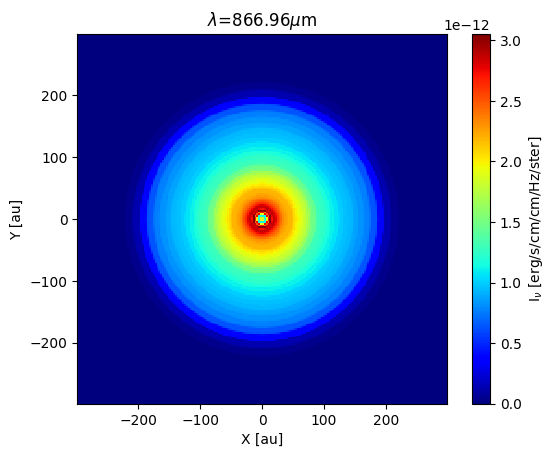

Successfully saved: Radmc3d_0_image_npix_200_incl_0_posang_0_sizeau_600_iline_3_CO_vkms_0.png


In [11]:
# LOADING AND PLOTTING IMAGE
im = cas.load_and_plot_image(thermal_path,image_name, flying_saucer_params,plot=False,cmap='jet',log=False,arcsec=False,save_png=True)

In [12]:
# DEFINING FOLDER PATH
base_path = Path("/home/fmeyer/Stage")
image_folder = base_path / image_name

In [13]:
# WRITING FITS IMAGE FOR CASA
cas.write_fits(image_folder, image_name, flying_saucer_params, im, interactive=False, casa=True,verbose=False)


=== STARTING CASA SIMULATION PIPELINE ===
--> Converting image_npix_200_incl_0_posang_0_sizeau_600_iline_3_CO_vkms_0.fits to native CASA .image model...
--> Simulating subarray block 0: alma.cycle10.5.cfg -> obs_block_0


2026-06-23 10:42:46	WARN	importfits::::casa	This image has no beam or angular resolution provided, so you will not receive warnings from
2026-06-23 10:42:46	WARN	importfits::::casa+	tasks such as imregrid if your image pixels do not sample the the angular resolution well.
2026-06-23 10:42:46	WARN	importfits::::casa+	(This only affects warnings, not any functionality).
2026-06-23 10:42:46	WARN	importfits::::casa+	Providing a beam and brightness units in an image can also be useful for flux calculations.
2026-06-23 10:42:46	WARN	importfits::::casa+	If you wish to add a beam or brightness units to your image, please use
2026-06-23 10:42:46	WARN	importfits::::casa+	the "beam" parameter or ia.setrestoringbeam() and ia.setbrightnessunit()
2026-06-23 10:43:33	WARN	noise::CTPatchedInterp::interpolate	In caltable obs_block_0.alma.cycle10.5.noisy.T.cal_sim_temp (Tf Jones):
2026-06-23 10:43:33	WARN	noise::CTPatchedInterp::interpolate+	 Insufficient solution channel sampling (nchan=1) for frequenc

--> Simulating subarray block 1: alma.cycle10.3.cfg -> obs_block_1


2026-06-23 10:43:53	WARN	noise::CTPatchedInterp::interpolate	In caltable obs_block_1.alma.cycle10.3.noisy.T.cal_sim_temp (Tf Jones):
2026-06-23 10:43:53	WARN	noise::CTPatchedInterp::interpolate+	 Insufficient solution channel sampling (nchan=1) for frequency-dependent LINEAR interpolation 
2026-06-23 10:43:53	WARN	noise::CTPatchedInterp::interpolate+	 of calibration for MS spw=0; using NEAREST instead.


--> Merging tracking sets: ['obs_block_0/obs_block_0.alma.cycle10.5.ms', 'obs_block_1/obs_block_1.alma.cycle10.3.ms']
--> Executing tclean synthesis imaging (MFS mode)...
    [Forced Beam Target] bmaj: 0.27arcsec | bmin: 0.19arcsec | pa: 100deg



0%....10....20....30....40....50....60....70....80....90....100%

0%....10....20....30....40....50....60....70....80....90....100%

0%....10....20....30....40....50....60....70....80....90....100%

0%....10....20....30....40....50....60....70....80....90....100%
2026-06-23 10:45:02	WARN	SDAlgorithmMSClean::takeOneStep (file /source/casa6/casatools/src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging

0%....10....20....30....40....50....60....70....80....90....100%

0%....10....20....30....40....50....60....70....80....90....100%
2026-06-23 10:45:30	WARN	SDAlgorithmMSClean::takeOneStep (file /source/casa6/casatools/src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging

0%....10....20....30....40....50....60....70....80....90....100%

0%....10....20....30....40....50....60....70....80....90....100%
2026-06-23 10:45:56	WARN	SIImageStor

--> Hard-coding user-defined beam parameters into CASA image headers...
--> Exporting final locked deconvolution to image_final.fits...
=== CASA PIPELINE SUCCESSFUL ===



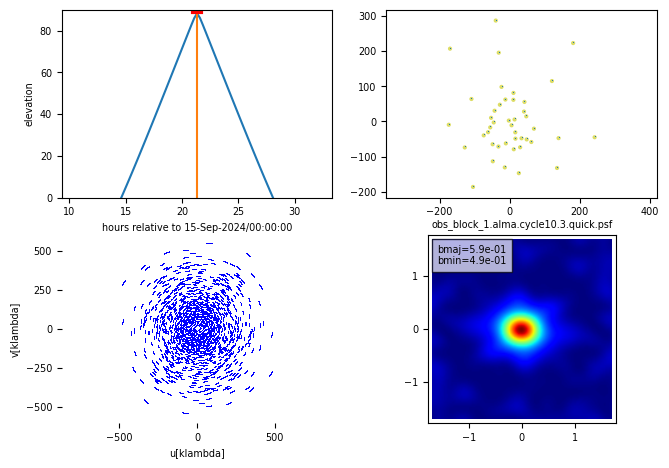

In [14]:
# RUNNING CASA PIPELINE TO SIMULATE REAL OBSERVATIONS
cas.casa_pipeline(
    Path("/home/fmeyer/Stage/"),
    image_name,
    flying_saucer_params,
    alma_observations,
    im,  
    widthkms=None,
    verbose=True)

Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


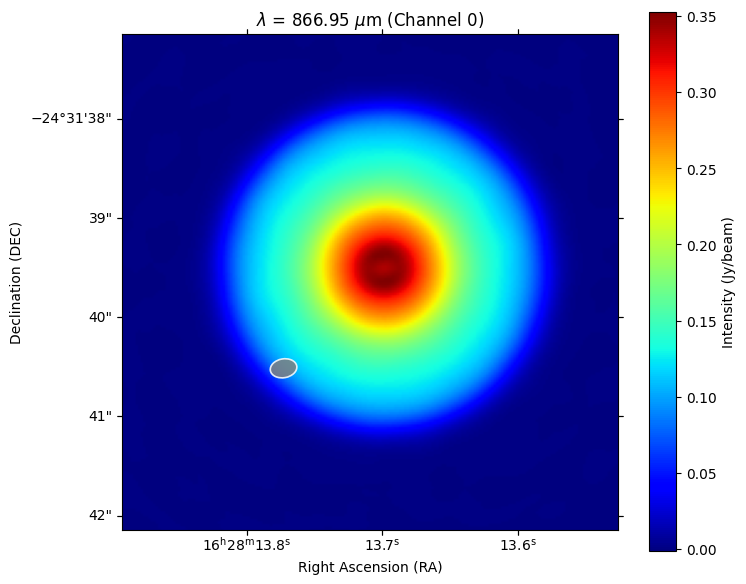

In [15]:
# PLOTTING CASA OUTPUTS
cas.plot_spectral_cube(
    image_folder,
    filename="image_final.fits",
    cmap="jet",
    figsize=(8, 7),
    zoom_window=(150,350,150,350),
    channel_range=None,
    show_beam=True,
    beam_xy=(215, 215),
    output_prefix="image_plot",
    save_png=True,
    interactive_show=True,
    verbose=False,
)


=== Generating Astronomical Moment-0 Map ===
--> Invoking immoments engine...


2026-06-24 07:11:10	WARN	immoments::Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.00197705 arcsec which is less than the pixel diagonal length of 0.0353553 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size
2026-06-24 07:11:12	WARN	immoments::Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.00191659 arcsec which is less than the pixel diagonal length of 0.0353553 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size
2026-06-24 07:11:15	WARN	immoments::Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.00189924 arcsec which is less than the pixel diagonal length of 0.0353553 arcsec. Thus, the kernel is poor

--> Exporting structure to absolute 2D spatial FITS layer...
--> Synthesized Clean Beam overlay injected: bmaj=0.280" and bmin=0.250"


Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


[+] Static graphics frame exported successfully to: image_npix_200_incl_87.0_posang_-3.1_sizeau_600_iline_6_CS_widthkms_5_linenlam_26/plot_moment0.png


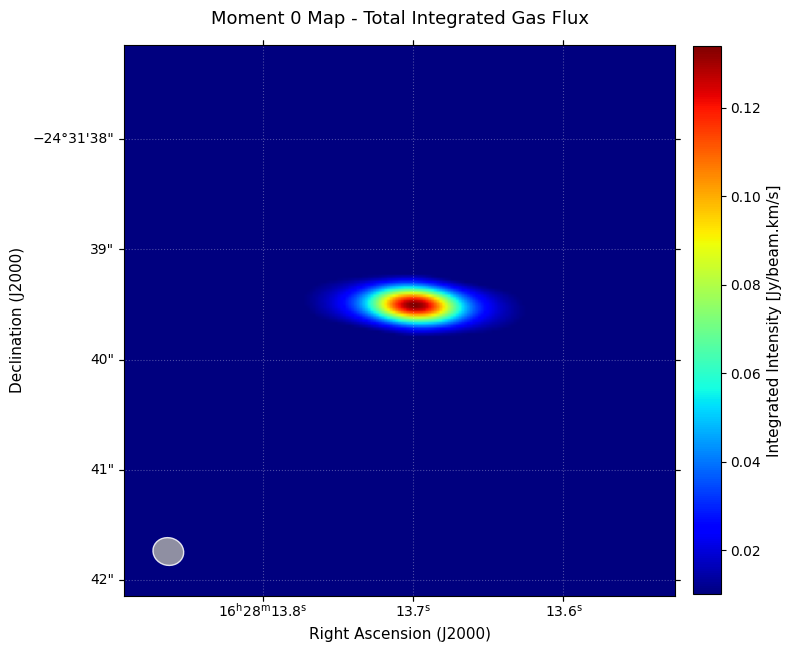

In [24]:
# MOMENT-M MAP 
image_folder = "image_npix_200_incl_87.0_posang_-3.1_sizeau_600_iline_6_CS_widthkms_5_linenlam_26"
cas.moment_map(image_folder,
           "image_final.fits",
           0,
           verbose=True,
           plot=True,
           save_png=True,
           scale_type="lin", 
           cmap="jet",
           zoom_window=[150,350,150,350],
           vmin=None,         
           vmax=None,
           beam=True
           )

Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


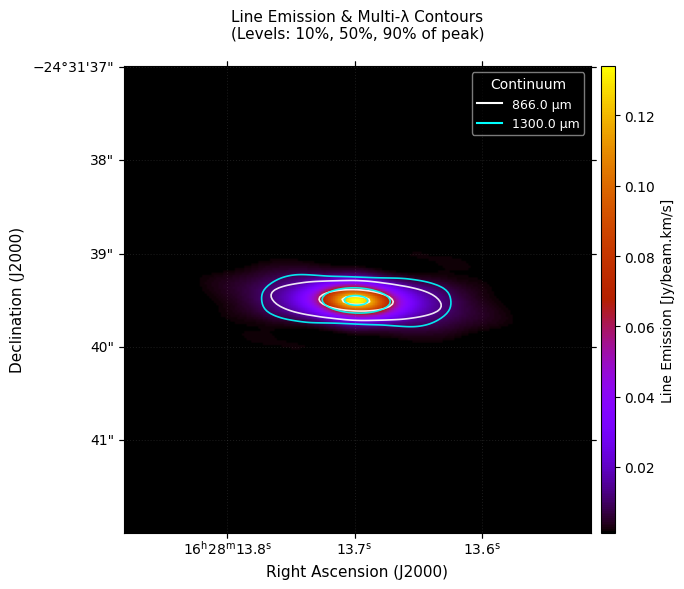

In [27]:
# PLOTTING LINE + CONTINUUM
# You need to run continuum for target wavelengths before running this function
cas.plot_line_with_multiple_continuum_contours(["image_npix_200_incl_87.0_posang_-3.1_sizeau_600_lambda_866/image_final.fits",
                                            "image_npix_200_incl_87_posang_-3.1_sizeau_600_lambda_1300/image_final.fits"], 
                                 "image_npix_200_incl_87.0_posang_-3.1_sizeau_600_iline_6_CS_widthkms_5_linenlam_26/map_moment0.fits",
                                  cmap="gnuplot",
                                  cont=[10,50,90],
                                 zoom_window=(156,356,156,356),
                                     save_png=True,
                                     figsize=(7,6))